In [41]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Pada tahap ini dilakukan impor berbagai library dan modul yang diperlukan untuk seluruh alur kerja pengolahan citra, ekstraksi fitur, klasifikasi, hingga evaluasi model. Library os digunakan untuk berinteraksi dengan sistem operasi, seperti mengakses dan mengelola struktur folder dataset. OpenCV (cv2) berfungsi untuk membaca, memanipulasi, dan memproses citra digital. NumPy (np) digunakan untuk menangani komputasi numerik dan operasi array multidimensi, sedangkan Matplotlib (plt) digunakan untuk menampilkan citra maupun grafik hasil analisis. Pandas (pd) digunakan untuk menyimpan dan mengorganisasi data hasil ekstraksi fitur ke dalam bentuk tabel (DataFrame). Untuk kebutuhan machine learning, library scikit-learn (sklearn) menyediakan modul train_test_split dan cross_val_predict untuk pembagian data serta validasi silang. Algoritma klasifikasi yang digunakan meliputi RandomForestClassifier, SVC (Support Vector Classifier), dan KNeighborsClassifier. Guna mengekstrak fitur tekstur dari citra, digunakan fungsi graycomatrix dan graycoprops dari skimage.feature untuk perhitungan matriks GLCM, didukung oleh scipy.stats untuk menghitung nilai entropi. Terakhir, evaluasi performa model dilakukan menggunakan berbagai metrik seperti akurasi, presisi, recall, f1-score, serta confusion_matrix yang divisualisasikan secara estetis menggunakan ConfusionMatrixDisplay dan library seaborn (sns).

In [42]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 500
Kelas: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


Pada tahap ini, dilakukan inisialisasi list kosong (data, labels, file_name) serta penentuan dimensi standar IMG_SIZE sebesar 128 x 128 piksel sebagai persiapan pemrosesan data. Menggunakan perulangan bertingkat (nested loop) dengan fungsi os.listdir dan os.path.join, program otomatis menelusuri setiap sub-folder di dalam direktori "dataset" untuk membaca file citra menggunakan OpenCV (cv.imread). Terdapat proses validasi (if img is None) untuk melewati file yang rusak, sedangkan citra yang valid akan disimpan ke dalam list bersama dengan nama sub-folder sebagai label kelas dan format penamaan baru yang terstruktur.

In [43]:
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
	pass
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  500
Data setelah augmentasi:  0


Pada tahap ini, dipersiapkan struktur untuk proses augmentasi data dengan menginisialisasi beberapa list baru (data_augmented, labels_augmented, paths_augmented, file_name_augmented) yang akan menampung hasil manipulasi citra. Sebuah perulangan for disiapkan untuk mengiterasi seluruh citra asli guna menerapkan teknik augmentasi nantinya, meskipun saat ini blok tersebut masih berupa kerangka acuan (placeholder menggunakan perintah pass). Di akhir proses, program mencetak perbandingan jumlah data antara sebelum dan setelah dilakukan augmentasi untuk memantau performa serta penambahan variasi dataset secara keseluruhan.

# Data Preparation
### Define Preprocessing Function

In [44]:
TARGET_SIZE = (128, 128)

def re_gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_hasil = cv.medianBlur(img, kernel_size)
    return median_hasil

Di sini, ukuran target citra ditetapkan sebesar 128 x 128 piksel diikuti dengan pembuatan dua fungsi preprocessing, yaitu re_gray dan median. Fungsi re_gray dipakai untuk mengubah resolusi gambar sekaligus mengecek jumlah channel-nya jika masih berformat BGR (berwarna), gambar akan langsung dikonversi ke grayscale dengan tipe data uint8. Sedangkan fungsi median digunakan untuk mereduksi noise memakai cv.medianBlur, lengkap dengan validasi di awal untuk memastikan apakah input yang masuk berupa path string (yang harus dibaca dulu) atau sudah berupa matriks gambar siap pakai.

In [ ]:
def prepro(image):
    img = re_gray(image)
    img = median(img)

    return img

Fungsi prepro ini dibuat untuk menyatukan langkah prapemrosesan gambar ke dalam satu alur kerja. Gambar masukan bakal otomatis diubah ukurannya sekaligus dikonversi ke skala keabuan lewat fungsi re_gray, lalu langsung dibersihkan dari noise menggunakan fungsi median sebelum akhirnya dikembalikan sebagai output matriks yang baru.

## Percobaan 1 (Grayscale + Resize + Median Filter)

Fungsi percobaan1 dibuat untuk memproses satu gambar lewat fungsi prepro, yang kemudian dieksekusi ke seluruh elemen data menggunakan list comprehension untuk disimpan di dalam dataPreprocessed. Variabel unique_labels menampung daftar kategori unik dari hasil operasi sorted(set(labels)) sebagai dasar perulangan setiap kelas. Di dalam perulangan tersebut, variabel idxs mengumpulkan semua indeks gambar yang cocok dengan label yang sedang aktif. Selanjutnya, plt.subplots(4, 6) menyiapkan grid 4 baris dan 6 kolom, di mana perulangan for k pertama menghitung posisi baris lewat k // 6 dan kolom lewat k % 6 untuk menampilkan maksimal 24 gambar menggunakan ax.imshow dengan cmap='gray' sekaligus mematikan sumbunya lewat ax.axis('off'). Perulangan for k yang kedua kemudian berjalan dari sisa jumlah gambar hingga batas kotak 24 untuk ikut menonaktifkan sumbu pada grid yang kosong agar visualisasi akhirnya terlihat rapi.

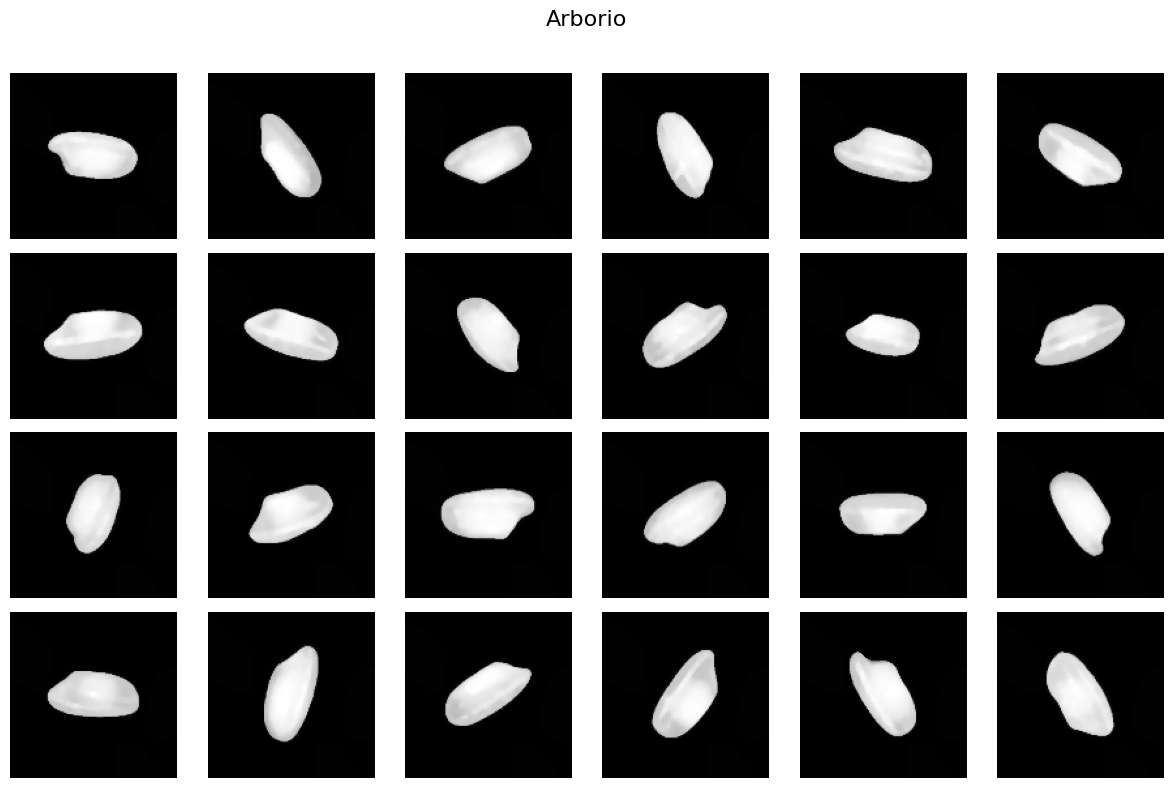

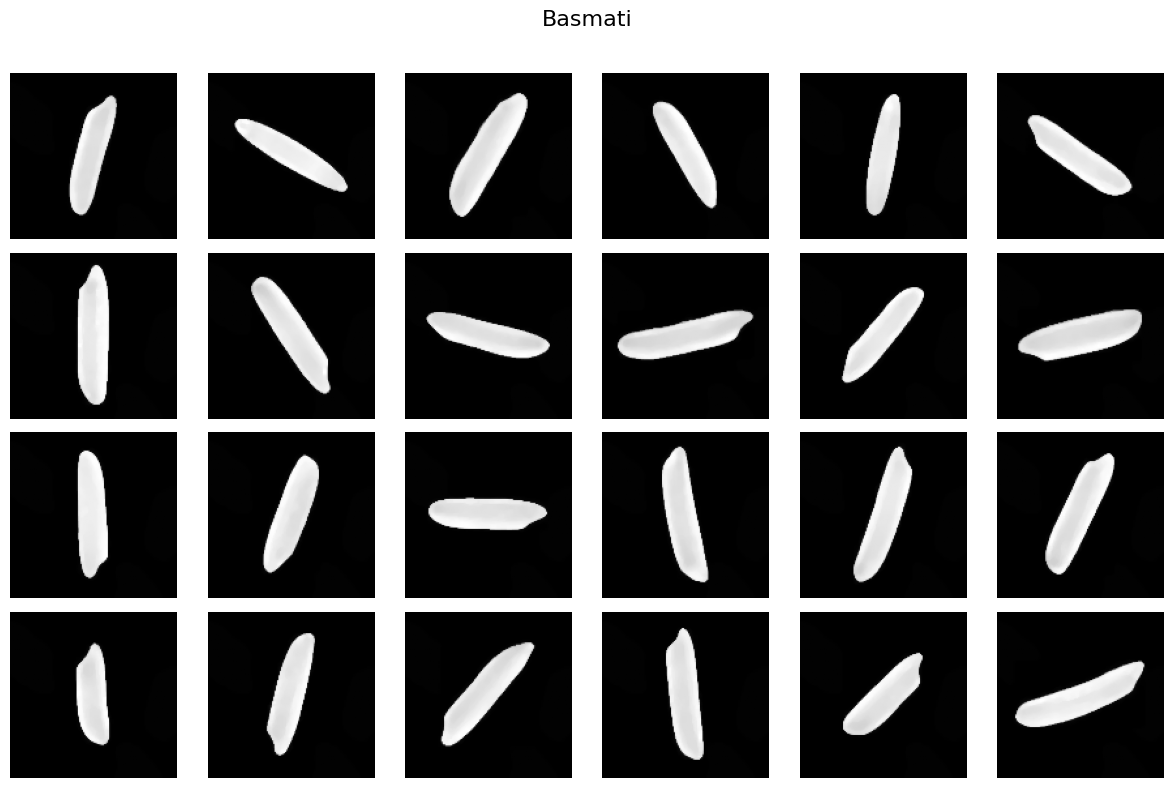

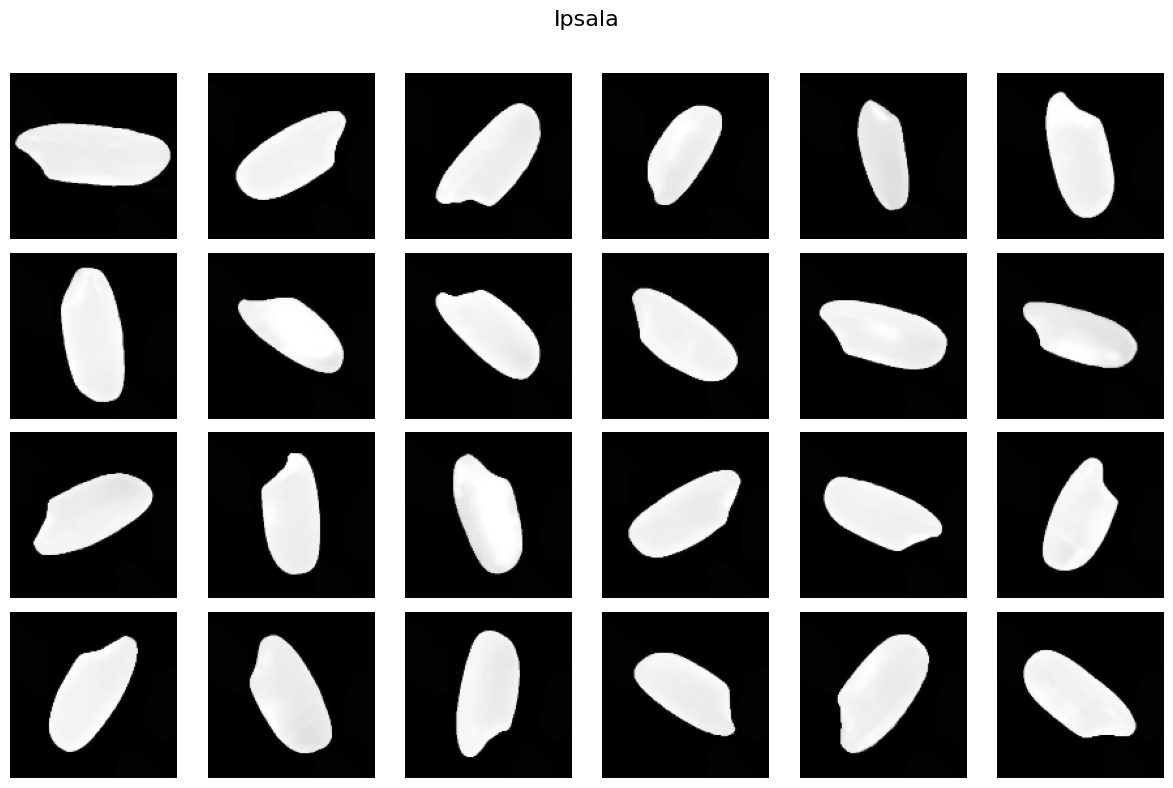

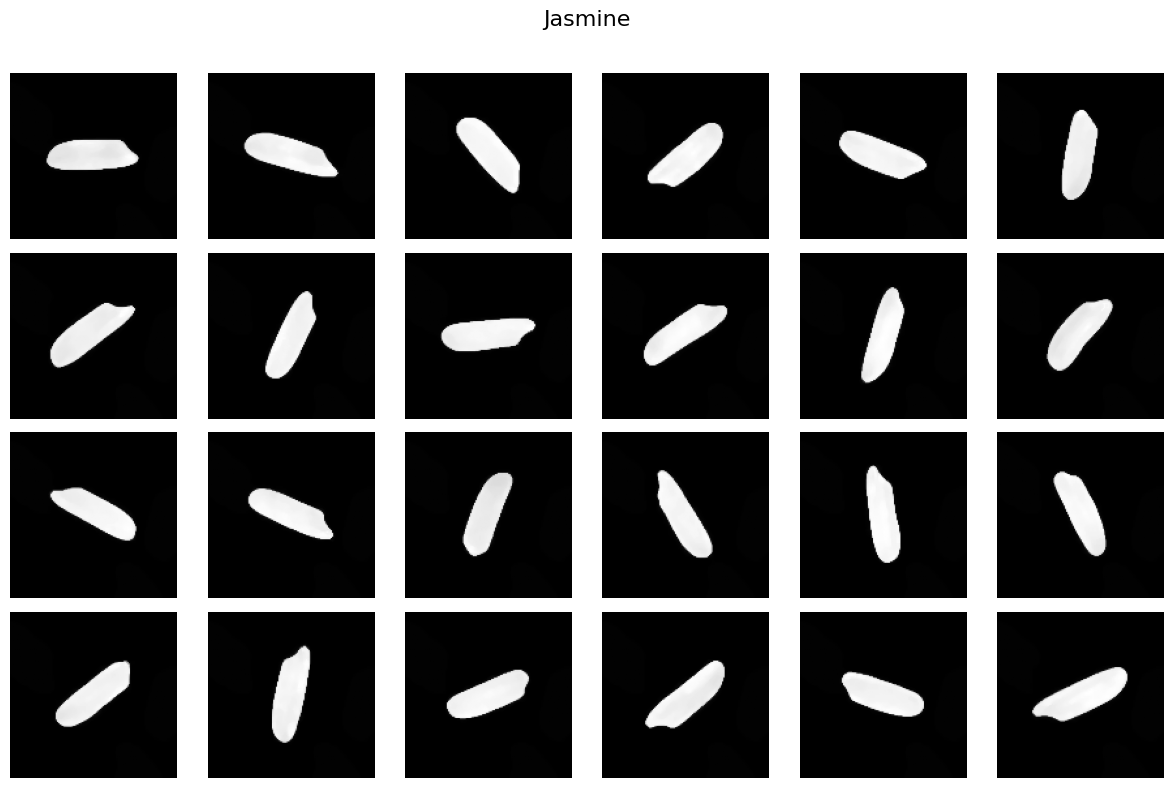

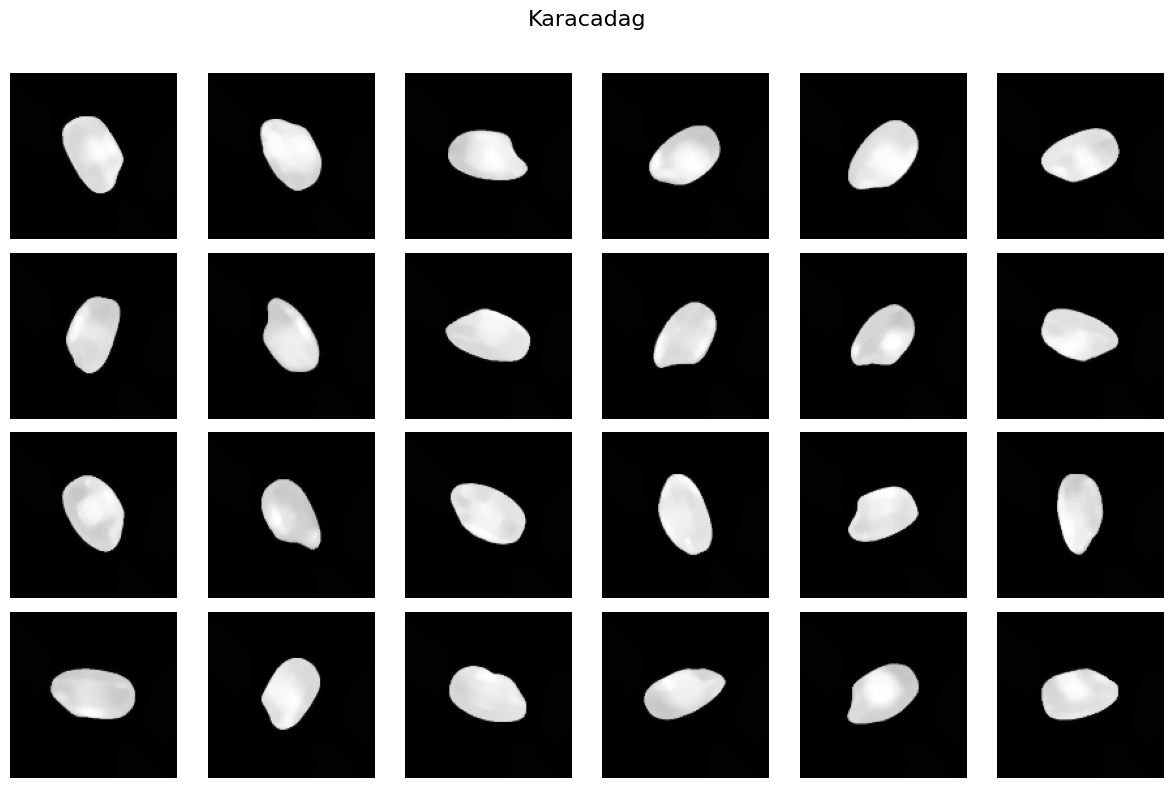

In [46]:
def percobaan1(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan1(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    for k in range(min(24, len(idxs)), 24):
        row = k // 6
        col = k % 6
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [47]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Fungsi glcm menerima parameter berupa image dan derajat untuk menghitung matriks ko-okurensi aras keabuan. Di dalam fungsi, blok kondisi if-elif-else bertugas memetakan nilai sudut input (0, 45, 90, atau 135 derajat) ke dalam bentuk radian seperti np.pi / 4 untuk sudut 45 derajat dan seterusnya di dalam variabel angles, serta memunculkan pesan ValueError jika input sudut tidak sesuai ketentuan. Variabel angles tersebut kemudian dimasukkan ke fungsi graycomatrix bersama dengan jarak piksel [1], jumlah level keabuan 256, serta pengaturan symmetric=True untuk menghasilkan matriks simetris dan normed=True untuk menormalisasi nilai matriks menjadi probabilitas.

In [48]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Blok kode ini mendefinisikan tujuh fungsi modular untuk mengekstrak fitur statistik dari matriks GLCM yang dikirim melalui parameter matriks. Enam fungsi pertama, yaitu correlation_feat, dissimilarity, homogenity, contrast, ASM, dan energy, memanfaatkan fungsi graycoprops dengan memasukkan argumen nama properti tekstur yang bersesuaian. Karena keluaran dari graycoprops berupa array dua dimensi, ditambahkan indeks [0, 0] di setiap akhir baris kode untuk mengambil nilai skalar tunggalnya secara langsung. Sementara itu, fungsi entropyGlcm menggunakan pendekatan berbeda dengan mengubah matriks GLCM menjadi array satu dimensi terlebih dahulu lewat metode .ravel() sebelum menghitung nilai entropi distribusinya menggunakan fungsi entropy.

In [49]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 500 citra.


Blok kode ini diawali dengan menginisialisasi empat list kosong, yaitu Derajat0, Derajat45, Derajat90, dan Derajat135, untuk menampung matriks hasil perhitungan GLCM. Perulangan for pertama berjalan berdasarkan panjang data dari dataPreprocessed untuk menghitung matriks ko-okurensi dari setiap gambar pada empat sudut arah yang berbeda melalui fungsi glcm, lalu memasukkan hasilnya ke masing-masing list derajat tersebut memakai metode append. Selanjutnya, dilakukan inisialisasi massal untuk puluhan list kosong baru yang dikelompokkan berdasarkan nama fitur statistik dan sudutnya, seperti Kontras0 hingga correlation135. Perulangan for kedua kemudian mengeksekusi proses ekstraksi dengan cara mengambil matriks GLCM dari setiap gambar di setiap sudut, menghitung nilai skalarnya melalui fungsi fitur yang cocok seperti contrast, dissimilarity, homogenity, entropyGlcm, ASM, energy, dan correlation_feat, lalu menyimpannya ke dalam list fitur yang bersesuaian.

## Ekstraksi ke CSV

Pada tahap ini, dibuat sebuah dictionary bernama dataTable yang berfungsi untuk memetakan nama kolom seperti Filename, Label, dan seluruh fitur tekstur hasil ekstraksi ke list datanya masing-masing. Kumpulan data tersebut kemudian dikonversi menjadi struktur tabel tabular lewat fungsi pd.DataFrame dan diekspor menjadi file dokumen dengan format CSV menggunakan perintah to_csv ke dalam jalur folder hasil_ekstraksi tanpa membawa indeks barisnya. Setelah berhasil tersimpan, file hasil_ekstraksi1.csv tersebut dibaca kembali ke dalam memori program menggunakan fungsi pd.read_csv ke dalam variabel hasilEkstrak untuk memunculkan pratinjau seluruh baris dan kolom data di layar.

In [50]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi1.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Arborio_1.jpg,Arborio,88.282296,236.251411,214.841412,288.538719,0.917343,0.893329,0.898076,0.885169,...,0.452539,0.445017,0.675974,0.671258,0.672710,0.667096,0.990487,0.974715,0.976849,0.969119
1,Arborio_2.jpg,Arborio,198.567975,165.321905,135.167938,374.746543,0.893350,0.903203,0.906444,0.875516,...,0.438147,0.427203,0.661261,0.659639,0.661927,0.653608,0.979653,0.983175,0.986149,0.961861
2,Arborio_3.jpg,Arborio,97.295337,260.206150,160.751722,164.892740,0.899503,0.876256,0.887580,0.885397,...,0.438037,0.431441,0.663742,0.658324,0.661843,0.656842,0.989341,0.971686,0.982388,0.982057
3,Arborio_4.jpg,Arborio,198.114973,180.769484,107.533834,319.091016,0.900167,0.900713,0.918039,0.881527,...,0.442064,0.430643,0.663237,0.661102,0.664879,0.656234,0.978426,0.980448,0.988290,0.965488
4,Arborio_5.jpg,Arborio,103.874446,237.319177,234.176796,328.473247,0.900099,0.873890,0.874904,0.853741,...,0.411843,0.405030,0.646046,0.641309,0.641750,0.636419,0.990170,0.977689,0.977838,0.969119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Karacadag_96.jpg,Karacadag,94.325849,139.735941,147.863189,265.888710,0.916003,0.899444,0.904267,0.895801,...,0.445371,0.437232,0.669451,0.666147,0.667361,0.661235,0.988884,0.983644,0.982574,0.968878
496,Karacadag_97.jpg,Karacadag,156.241818,280.259595,111.347441,166.036518,0.921968,0.903511,0.918284,0.902221,...,0.454406,0.445907,0.673284,0.669045,0.674097,0.667762,0.979339,0.963195,0.985275,0.978196
497,Karacadag_98.jpg,Karacadag,101.631459,234.992560,110.481176,124.475231,0.914022,0.895465,0.914174,0.901493,...,0.445394,0.437526,0.667181,0.662299,0.667378,0.661457,0.987113,0.970406,0.985990,0.984324
498,Karacadag_99.jpg,Karacadag,142.801489,155.289169,127.380290,283.925538,0.918598,0.915553,0.922542,0.895960,...,0.457004,0.447307,0.676443,0.673713,0.676020,0.668810,0.980546,0.978991,0.982646,0.961588


## Feature Selection

Baris pertama menghitung matriks korelasi antar fitur numerik menggunakan fungsi corr setelah membuang kolom Label dan Filename lewat drop. Nilai threshold ditetapkan sebesar 0.95, diikuti pembuatan array boolean bernama columns berisi nilai True untuk menandai fitur yang akan dipertahankan. Melalui perulangan bersarang, program memeriksa nilai korelasi absolut antar pasangan fitur; jika korelasi tersebut mencapai atau melebihi threshold, status fitur pada indeks j akan diubah menjadi False karena dianggap redundan. Fitur-fitur yang tetap bernilai True kemudian diambil namanya dalam variabel select untuk menyaring data fitur baru ke x_new dan memisahkan target kelas ke y.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 13
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Entropy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


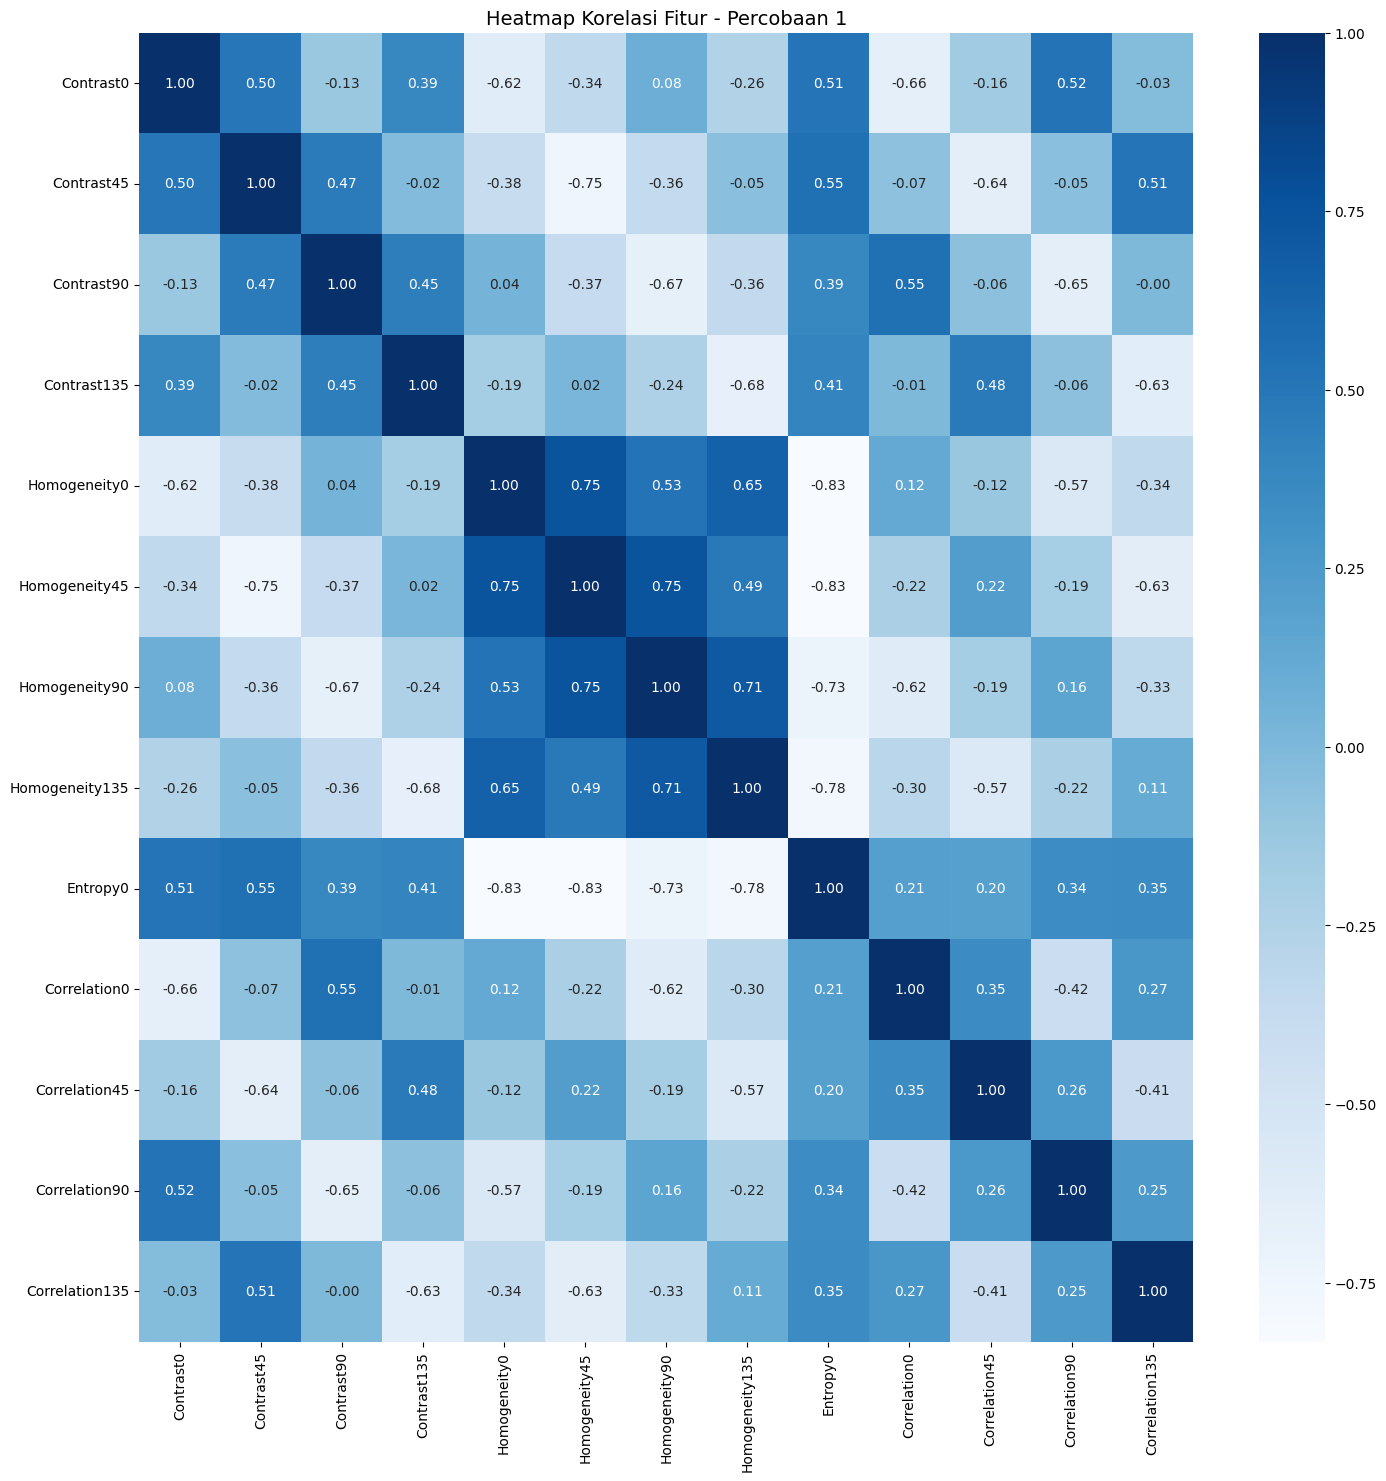

In [51]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 1', fontsize=14)
plt.show()

In [52]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(400, 13)
(100, 13)


## Splitting Data

Fungsi train_test_split digunakan untuk memisahkan data fitur x_new dan target y menjadi data latih serta data uji. Melalui parameter test_size=0.2, sebanyak 20 persen data dialokasikan untuk pengujian dan 80 persen sisanya digunakan untuk pelatihan model, didukung parameter random_state=42 untuk mengunci pola acak agar hasil pembagian selalu konsisten saat dijalankan ulang. Hasil pemisahan ini ditampung secara berurutan ke dalam variabel X_train, X_test, y_train, dan y_test. Bagian akhir kode memanggil properti shape di dalam fungsi print untuk menampilkan dimensi ukuran baris dan kolom dari X_train dan X_test guna memastikan proporsi data sudah terbagi dengan benar.

In [53]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Normalisasi Fitur

Dua baris awal digunakan untuk menghitung nilai rata-rata lewat fungsi mean dan standar deviasi lewat fungsi std khusus dari data latih X_train, yang kemudian disimpan ke dalam variabel mean_train dan std_train. Nilai statistik dari data latih tersebut lalu dipakai untuk melakukan standarisasi data atau Z-score normalization pada data uji X_test dan data latih X_train. Proses ini dilakukan dengan mengurangi setiap nilai fitur dengan mean_train lalu membaginya dengan std_train agar skala data menjadi seragam dengan rata-rata 0 dan standar deviasi 1, sekaligus mencegah terjadinya kebocoran data atau data leakage dari data uji.

# MODELING

In [54]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Define Model

Fungsi generateClassificationReport dibuat untuk menampilkan metrik evaluasi performa model klasifikasi secara langsung. Di dalam fungsi ini, terdapat perintah untuk mencetak classification_report yang berisi detail nilai presisi, recall, dan f1-score, confusion_matrix untuk melihat sebaran kecocokan prediksi dengan kelas asli, serta accuracy_score untuk menghitung skor akurasi keseluruhan.

Di bagian bawahnya, tiga model klasifikasi dideklarasikan sebagai objek terpisah. Variabel rf diisi oleh algoritma Random Forest dengan penentuan 5 pohon keputusan, variabel svm diisi oleh Support Vector Classifier yang berjalan menggunakan kernel rbf, dan variabel knn diisi oleh algoritma K-Nearest Neighbors dengan acuan 5 tetangga terdekat. Pengaturan nilai 42 pada parameter random_state di model Random Forest dan SVM dipasang khusus untuk mengunci pola acak agar hasil pengujian model tetap konsisten saat dijalankan ulang.

## Hasil Modeling Random Forest

Proses dimulai dengan melatih model Random Forest menggunakan pasangan data fitur X_train dan label y_train lewat perintah fit. Setelah model selesai mempelajari pola data, pengujian performa dilakukan pada dua kelompok data yang berbeda.

Pertama, program mencetak pembatas Training Set, memprediksi kembali label dari data latih menggunakan rf.predict, dan memunculkan laporan evaluasinya lewat fungsi generateClassificationReport. Kedua, langkah yang sama diulangi untuk data uji dengan mencetak pembatas Testing Set guna mengevaluasi prediksi model terhadap data X_test, sehingga hasil akurasi pada kedua kelompok data tersebut bisa langsung dibandingkan.

In [ ]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Arborio       0.99      0.99      0.99        72
     Basmati       0.99      1.00      0.99        86
      Ipsala       1.00      1.00      1.00        90
     Jasmine       1.00      0.97      0.99        76
   Karacadag       0.99      1.00      0.99        76

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400

[[71  0  0  0  1]
 [ 0 86  0  0  0]
 [ 0  0 90  0  0]
 [ 1  1  0 74  0]
 [ 0  0  0  0 76]]
Accuracy: 0.9925

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.93      0.96      0.95        28
     Basmati       0.88      1.00      0.93        14
      Ipsala       1.00      0.80      0.89        10
     Jasmine       1.00      0.92      0.96        24
   Karacadag       0.92      0.96      0.94        24

    accuracy               

## Hasil Modeling SVM

Proses diawali dengan melatih model SVM menggunakan pasangan data fitur X_train dan label y_train melalui perintah fit. Setelah model selesai mempelajari pola sebaran data, pengujian performa dilakukan pada kelompok data latih dan data uji secara bergantian.

Pertama, program mencetak pembatas teks Training Set ke layar, lalu memprediksi kembali label dari data latih menggunakan fungsi svm.predict untuk disimpan ke dalam variabel y_pred, kemudian menampilkan seluruh metrik evaluasinya lewat fungsi generateClassificationReport. Kedua, alur yang sama diterapkan pada data uji dengan mencetak pembatas Testing Set, menghasilkan prediksi dari data X_test ke variabel y_pred, dan mengevaluasinya kembali menggunakan fungsi laporan yang sama agar tingkat akurasi serta kemampuan generalisasi model bisa dianalisis dengan jelas.

In [56]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Arborio       0.98      0.82      0.89        72
     Basmati       1.00      1.00      1.00        86
      Ipsala       1.00      1.00      1.00        90
     Jasmine       0.97      1.00      0.99        76
   Karacadag       0.87      0.99      0.93        76

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400

[[59  0  0  2 11]
 [ 0 86  0  0  0]
 [ 0  0 90  0  0]
 [ 0  0  0 76  0]
 [ 1  0  0  0 75]]
Accuracy: 0.965

------Testing Set------
              precision    recall  f1-score   support

     Arborio       1.00      0.89      0.94        28
     Basmati       0.93      1.00      0.97        14
      Ipsala       1.00      0.90      0.95        10
     Jasmine       1.00      1.00      1.00        24
   Karacadag       0.89      1.00      0.94        24

    accuracy               

## Hasil Modeling KNN

Proses diawali dengan melatih model KNN menggunakan pasangan data fitur X_train dan label y_train melalui perintah fit. Setelah model selesai memetakan kedekatan pola data berdasarkan tetangganya, pengujian performa dilakukan pada kelompok data latih dan data uji secara bergantian.

Pertama, program mencetak pembatas teks Training Set ke layar, lalu memprediksi kembali label dari data latih menggunakan fungsi knn.predict untuk disimpan ke dalam variabel y_pred, kemudian menampilkan seluruh metrik evaluasinya lewat fungsi generateClassificationReport. Kedua, alur yang sama diterapkan pada data uji dengan mencetak pembatas Testing Set, menghasilkan prediksi dari data X_test ke variabel y_pred, dan mengevaluasinya kembali menggunakan fungsi laporan yang sama agar tingkat akurasi serta kemampuan generalisasi model KNN dalam mengenali data baru bisa dianalisis dengan jelas.

In [57]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Arborio       1.00      0.83      0.91        72
     Basmati       1.00      1.00      1.00        86
      Ipsala       1.00      1.00      1.00        90
     Jasmine       0.99      1.00      0.99        76
   Karacadag       0.87      1.00      0.93        76

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400

[[60  0  0  1 11]
 [ 0 86  0  0  0]
 [ 0  0 90  0  0]
 [ 0  0  0 76  0]
 [ 0  0  0  0 76]]
Accuracy: 0.97

------Testing Set------
              precision    recall  f1-score   support

     Arborio       1.00      0.93      0.96        28
     Basmati       0.93      1.00      0.97        14
      Ipsala       1.00      0.90      0.95        10
     Jasmine       1.00      1.00      1.00        24
   Karacadag       0.92      1.00      0.96        24

    accuracy                

## Evaluasi Confusion Matrix

Fungsi plot_confusion_matrix didefinisikan untuk menampilkan visualisasi matriks kontingensi atau confusion matrix dari hasil pengujian model. Di dalam fungsi tersebut, perhitungan nilai matriks dilakukan oleh fungsi confusion_matrix menggunakan parameter label asli y_true dan label prediksi y_pred. Hasil perhitungan ini kemudian dibungkus ke dalam objek ConfusionMatrixDisplay dan digambar secara visual melalui metode plot dengan skema gradasi warna biru menggunakan parameter cmap=plt.cm.Blues.

Pada baris-baris setelahnya, fungsi ini dipanggil sebanyak tiga kali secara berurutan untuk menggambarkan matriks evaluasi dari masing-masing model pada kelompok data testing. Pemanggilan pertama ditujukan untuk melihat penyebaran prediksi model Random Forest, pemanggilan kedua untuk model SVM, dan pemanggilan ketiga untuk model KNN. Setiap pemanggilan mengirimkan label asli y_test, hasil prediksi dari data uji X_test lewat fungsi predict, serta teks judul spesifik untuk grafik Percobaan 1.

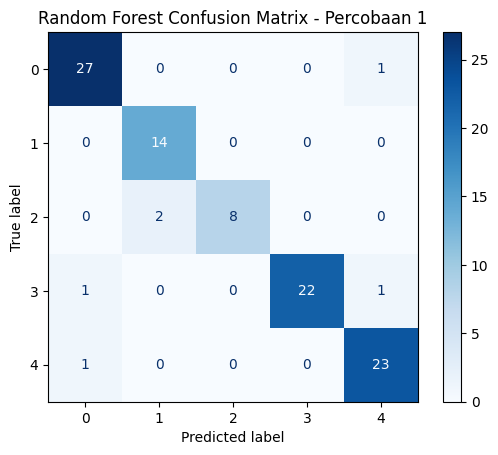

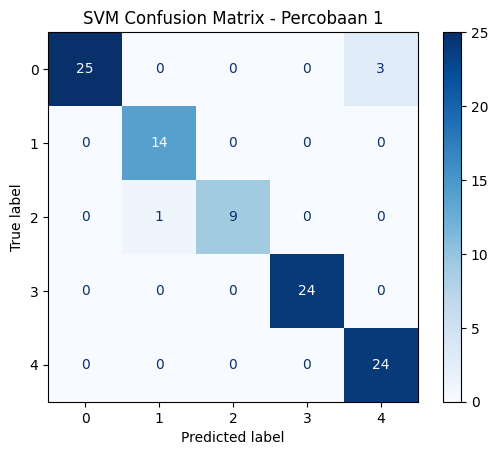

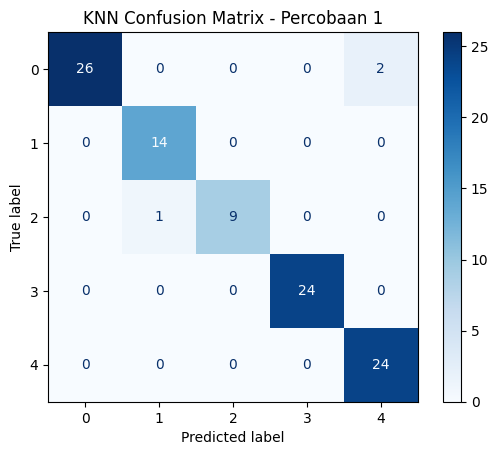

In [58]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 1")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 1")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 1")

## Simpan Hasil Klasifikasi ke CSV

Blok kode ini merangkum seluruh hasil evaluasi performa model Random Forest, SVM, dan KNN dengan mengumpulkan nilai akurasi latih, akurasi uji, presisi, recall, dan f1-score ke dalam sebuah dictionary. Perhitungan metrik pengujian menggunakan metode weighted untuk menyesuaikan bobot tiap kelas serta parameter zero_division untuk mencegah terjadinya error saat pembagian. Kumpulan data tersebut kemudian dikonversi menjadi tabel terstruktur lewat DataFrame pandas, diekspor langsung menjadi file CSV dengan nama hasil_klasifikasi1.csv di dalam folder hasil_klasifikasi tanpa menyertakan indeks baris, lalu diakhiri dengan memunculkan notifikasi sukses beserta pratinjau tabel ringkasnya di layar.

In [59]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./hasil_klasifikasi/hasil_klasifikasi1.csv', index=False)
print("✅ File hasil_klasifikasi1.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi1.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.9925,0.94,0.943990,0.94,0.939690
1,SVM,0.9650,0.96,0.964000,0.96,0.959943
2,KNN,0.9700,0.97,0.972205,0.97,0.969939
